In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd


In [2]:
np.random.seed(42)
X= np.random.rand(100,1)-0.5
y = 3*X[:,0]**2 + 0.05 * np.random.randn(100)

In [3]:
df = pd.DataFrame()
df['X'] = X.reshape(100)
df['y'] = y

In [4]:
df

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


Text(0.5, 1.0, 'X vs Y')

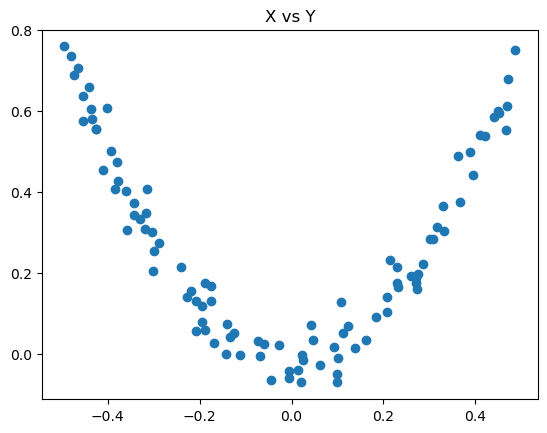

In [5]:
plt.scatter(df['X'], df['y'])
plt.title('X vs Y')

## Model 1

In [6]:
df['pred1'] = df['y'].mean()

In [7]:
df

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458
...,...,...,...
95,-0.006204,-0.040675,0.265458
96,0.022733,-0.002305,0.265458
97,-0.072459,0.032809,0.265458
98,-0.474581,0.689516,0.265458


In [8]:
df['res1'] = df['y'] - df['pred1']

In [9]:
df

,X,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528
...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133
96,0.022733,-0.002305,0.265458,-0.267763
97,-0.072459,0.032809,0.265458,-0.232650
98,-0.474581,0.689516,0.265458,0.424057


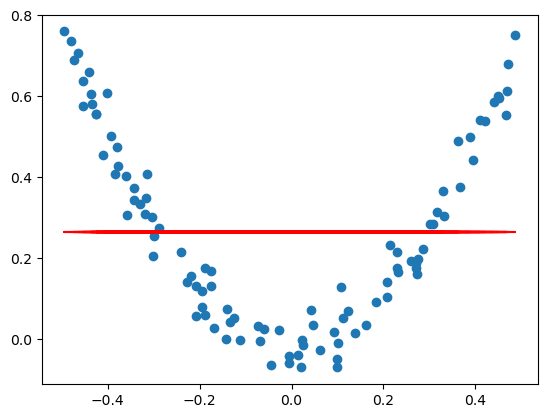

In [10]:
plt.scatter(df['X'], df['y'])
plt.plot(df['X'], df['pred1'], color= 'red' )

## Model 2

In [11]:
from sklearn.tree import DecisionTreeRegressor

In [12]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=8)

In [13]:
tree1.fit(df['X'].values.reshape(100,1),df['res1'])

DecisionTreeRegressor(max_leaf_nodes=8)

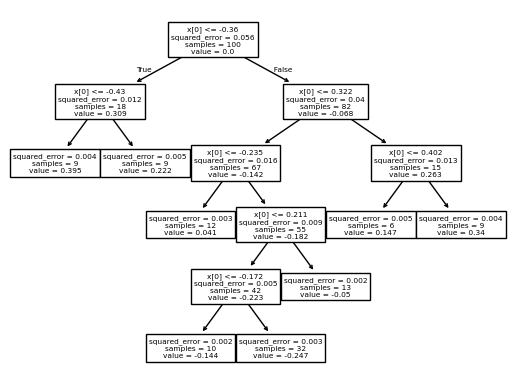

In [14]:
from sklearn.tree import plot_tree
from sympy import plot
plot_tree(tree1)
plt.show()

In [15]:
## generating X test
X_test = np.linspace(-0.5,0.5, 500)


In [19]:
y_pred = 0.265458 + tree1.predict(X_test.reshape(500,1))
y_pred.shape

(500,)

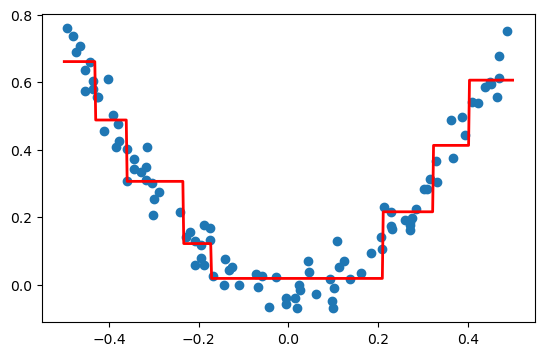

In [17]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test,y_pred,linewidth =2,color='red')
plt.scatter(df['X'],df['y'])

In [22]:
df['pred2'] =  0.265458 + tree1.predict(df['X'].values.reshape(100,1))

In [24]:
df['res2'] = df['y'] - df['pred2']

In [25]:
df

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319,-0.058994
96,0.022733,-0.002305,0.265458,-0.267763,0.018319,-0.020624
97,-0.072459,0.032809,0.265458,-0.232650,0.018319,0.014489
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028604


## Model 3

In [26]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)
tree2.fit(df['X'].values.reshape(100,1),df['res2'])

DecisionTreeRegressor(max_leaf_nodes=8)

In [27]:
ypred = 0.265458 + tree1.predict(X_test.reshape(500,1)) + tree2.predict(X_test.reshape(500,1))

In [42]:
y_pred = 0.265458 + tree2.predict(X_test.reshape(500,1)) + tree1.predict(X_test.reshape(500,1))
y_pred.shape

(500,)

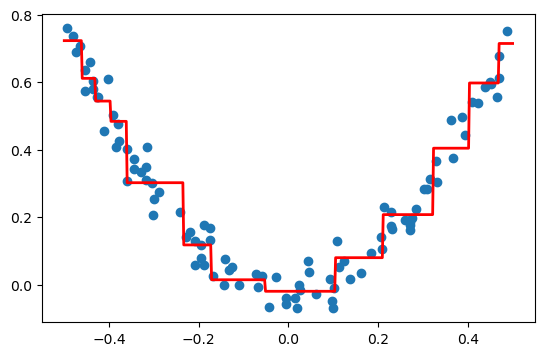

In [43]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test,y_pred,linewidth =2,color='red')
plt.scatter(df['X'],df['y'])

In [30]:
df['pred3'] = 0.265458 + tree1.predict(df['X'].values.reshape(100,1)) + tree2.predict(df['X'].values.reshape(100,1))
df['res3'] = df['y'] - df['pred3']

In [31]:
df

,X,y,pred1,res1,pred2,res2,pred3,res3
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254,0.014321,0.037252
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404,0.597523,-0.003043
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732,0.207423,-0.041371
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497,-0.019811,-0.050367
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022,0.301966,0.042020
...,...,...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319,-0.058994,-0.019811,-0.020864
96,0.022733,-0.002305,0.265458,-0.267763,0.018319,-0.020624,-0.019811,0.017506
97,-0.072459,0.032809,0.265458,-0.232650,0.018319,0.014489,0.014321,0.018488
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028604,0.722987,-0.033472


## Model 4

In [32]:
tree3 = DecisionTreeRegressor(max_leaf_nodes=8)
tree3.fit(df['X'].values.reshape(100,1),df['res3'])

DecisionTreeRegressor(max_leaf_nodes=8)

In [33]:
df['pred4'] = 0.265458 + tree1.predict(df['X'].values.reshape(100,1)) + tree2.predict(df['X'].values.reshape(100,1)) + tree3.predict(df['X'].values.reshape(100,1))


In [34]:
df['res4'] = df['y'] - df['pred4']

In [35]:
df

,X,y,pred1,res1,pred2,res2,pred3,res3,pred4,res4
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254,0.014321,0.037252,0.013090,0.038483
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404,0.597523,-0.003043,0.591609,0.002871
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732,0.207423,-0.041371,0.188148,-0.022097
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497,-0.019811,-0.050367,-0.021042,-0.049136
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022,0.301966,0.042020,0.300735,0.043251
...,...,...,...,...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319,-0.058994,-0.019811,-0.020864,-0.021042,-0.019633
96,0.022733,-0.002305,0.265458,-0.267763,0.018319,-0.020624,-0.019811,0.017506,-0.021042,0.018737
97,-0.072459,0.032809,0.265458,-0.232650,0.018319,0.014489,0.014321,0.018488,0.013090,0.019719
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028604,0.722987,-0.033472,0.721756,-0.032241


In [44]:
y_pred = 0.265458 + tree2.predict(X_test.reshape(500,1)) + tree1.predict(X_test.reshape(500,1)) + tree3.predict(X_test.reshape(500,1))
y_pred.shape

(500,)

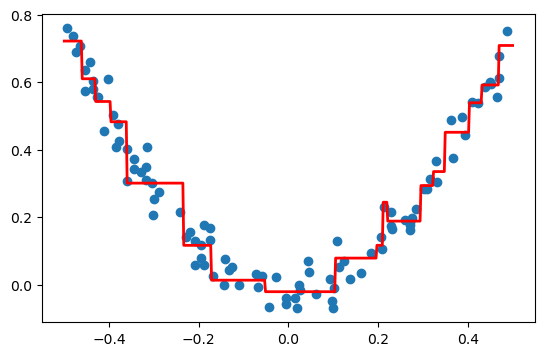

In [46]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test,y_pred,linewidth =2,color='red')
plt.scatter(df['X'],df['y'])

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

def gradient_boost(X, y, number, lr, count=1, regs=[], foo=None):
    if number == 0:
        return
    else:
        if count > 1:
            y = foo - sum(lr * tree.predict(X) for tree in regs)
        else:
            foo = y  # keep original y for final predictions

        tree_reg = DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)
        tree_reg.fit(X, y)
        regs.append(tree_reg)

        # use actual range of X for plotting
        x1 = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
        y_pred = sum(lr * tree.predict(x1) for tree in regs)

        print(f"Iteration {count}")
        plt.figure()
        plt.scatter(X, foo, label='True targets')
        plt.plot(x1, y_pred, linewidth=2, color='red', label='Boosted prediction')
        plt.legend()
        plt.title(f"Boosting Iteration {count}")
        plt.show()

        gradient_boost(X, y, number-1, lr, count+1, regs, foo)


Iteration 1


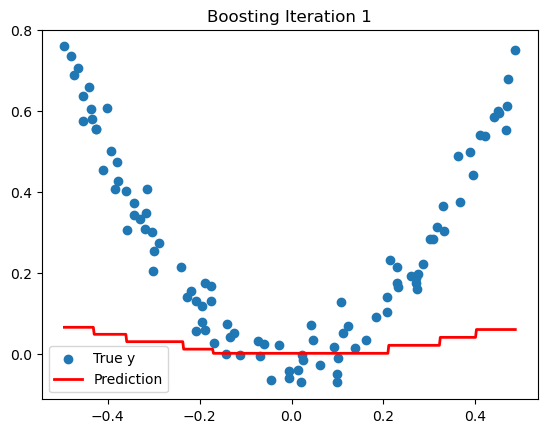

Iteration 2


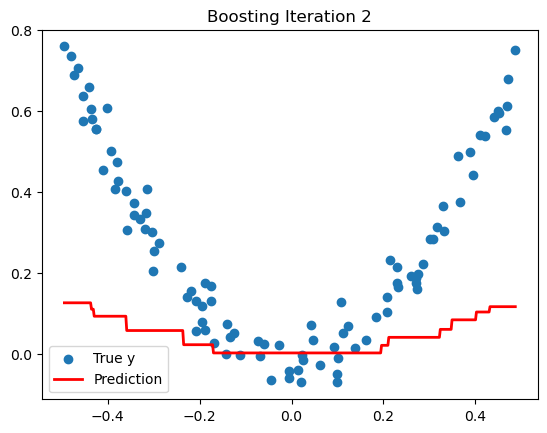

Iteration 3


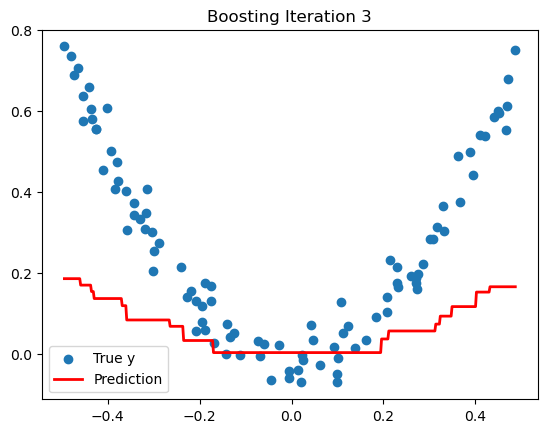

Iteration 4


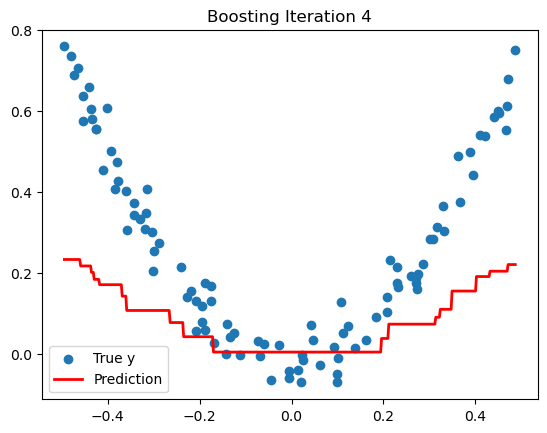

Iteration 5


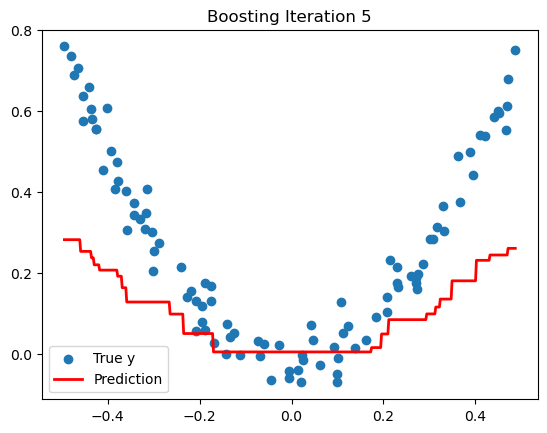

Iteration 6


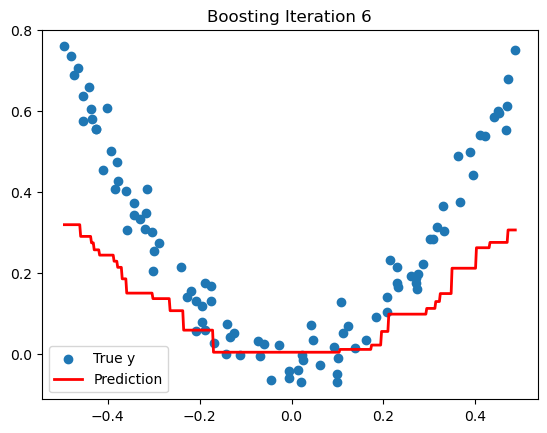

Iteration 7


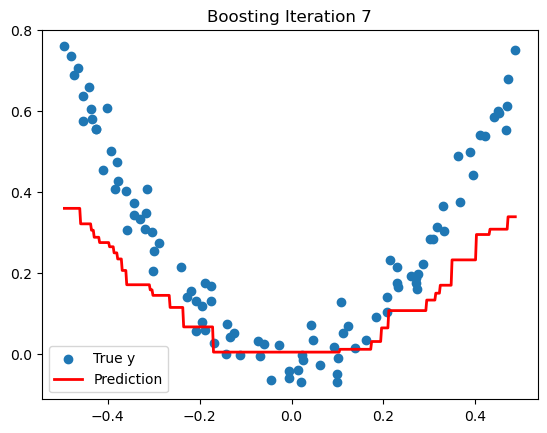

Iteration 8


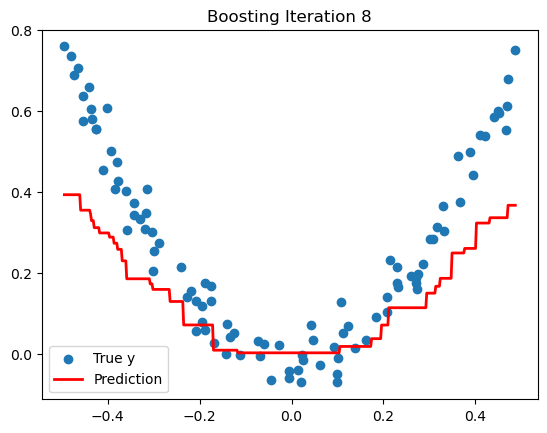

Iteration 9


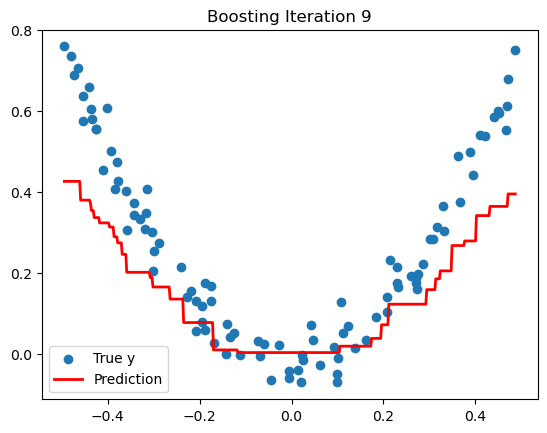

Iteration 10


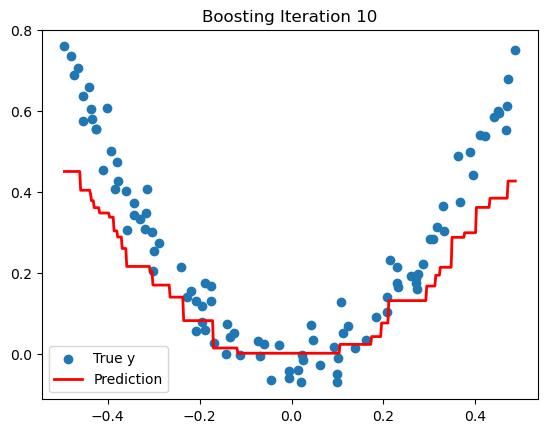

Iteration 11


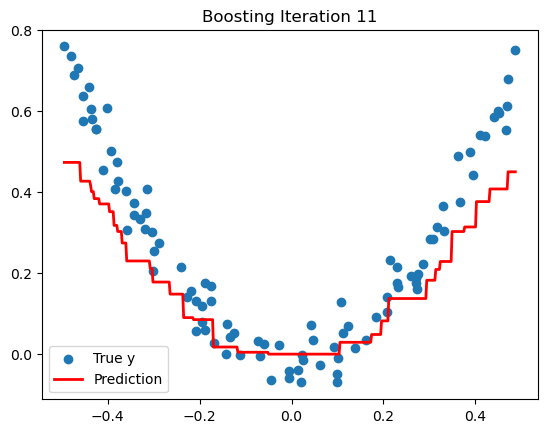

Iteration 12


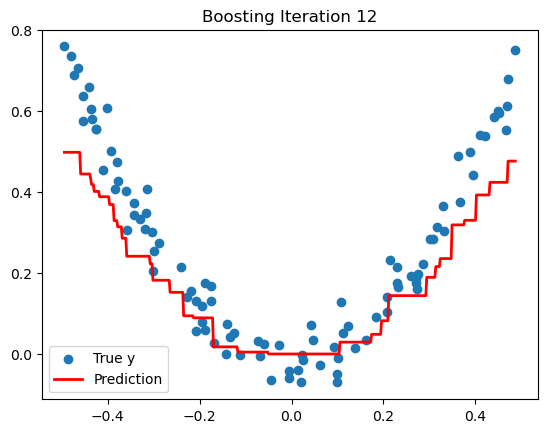

Iteration 13


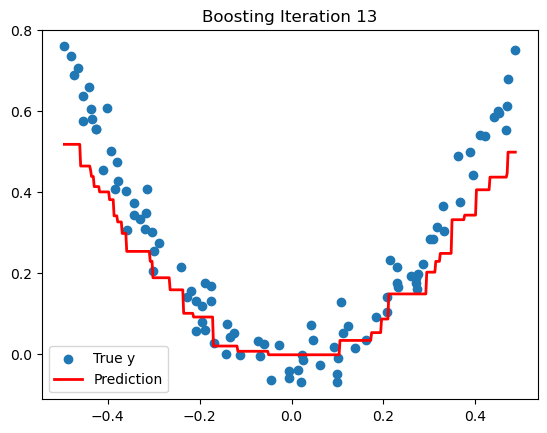

Iteration 14


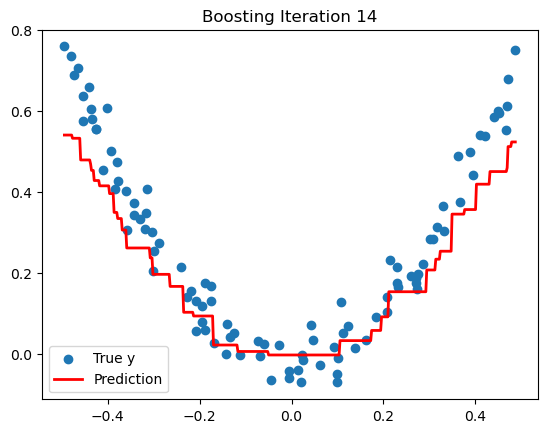

Iteration 15


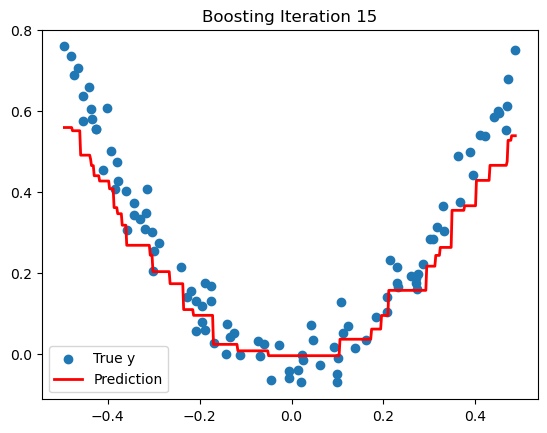

Iteration 16


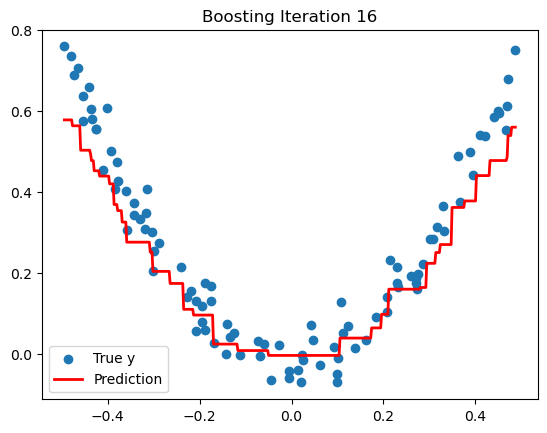

Iteration 17


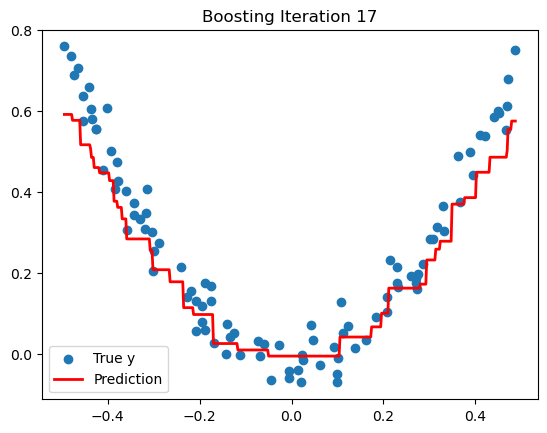

Iteration 18


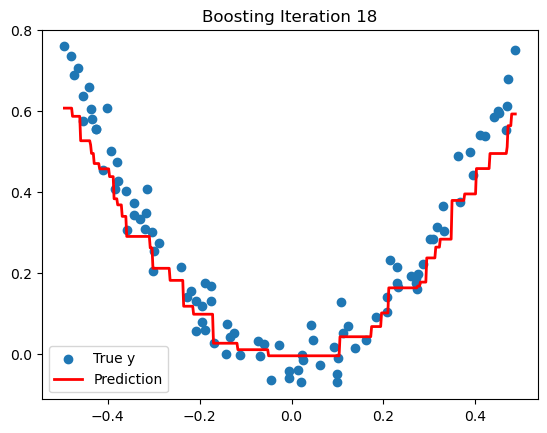

Iteration 19


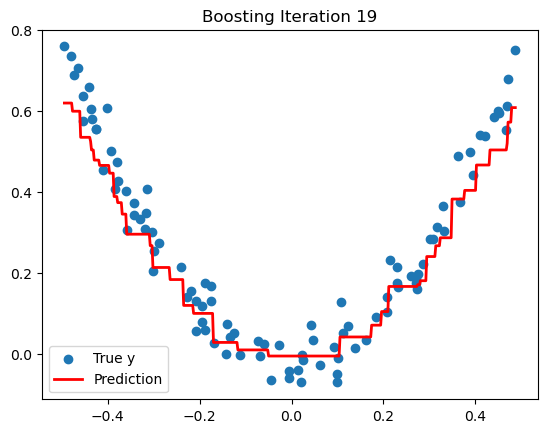

Iteration 20


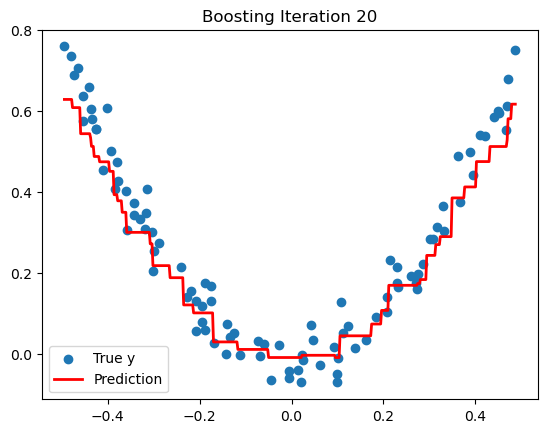

,X,y,residual1,pred1,residual2,pred2,residual3,pred3,residual4,pred4,...,residual16,pred16,residual17,pred17,residual18,pred18,residual19,pred19,residual20,pred20
0,-0.125460,0.051573,0.051573,0.001832,0.049741,0.002784,0.048789,0.003641,0.047932,0.004898,...,0.027616,0.024618,0.026955,0.026012,0.025561,0.026742,0.024830,0.028761,0.022812,0.029986
1,0.450714,0.594480,0.594480,0.060588,0.533891,0.117035,0.477445,0.166212,0.428268,0.204607,...,0.128386,0.477946,0.116534,0.486152,0.108328,0.495280,0.099200,0.504074,0.090405,0.512557
2,0.231994,0.166052,0.166052,0.021578,0.144473,0.041309,0.124743,0.057013,0.109038,0.073878,...,0.008725,0.160199,0.005853,0.162784,0.003268,0.163514,0.002537,0.166956,-0.000905,0.169790
3,0.098658,-0.070178,-0.070178,0.001832,-0.072010,0.002784,-0.072962,0.003641,-0.073819,0.004898,...,-0.066161,-0.003357,-0.066821,-0.005002,-0.065176,-0.004271,-0.065907,-0.004852,-0.065326,-0.008657
4,-0.343981,0.343986,0.343986,0.030596,0.313389,0.058133,0.285853,0.084196,0.259790,0.107652,...,0.075330,0.276346,0.067640,0.284333,0.059653,0.290488,0.053498,0.296027,0.047959,0.300594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-0.006204,-0.040675,-0.040675,0.001832,-0.042507,0.002784,-0.043459,0.003641,-0.044316,0.004898,...,-0.036658,-0.003357,-0.037319,-0.005002,-0.035673,-0.004271,-0.036404,-0.004852,-0.035823,-0.008524
96,0.022733,-0.002305,-0.002305,0.001832,-0.004137,0.002784,-0.005089,0.003641,-0.005945,0.004898,...,0.001712,-0.003357,0.001052,-0.005002,0.002697,-0.004271,0.001967,-0.004852,0.002547,-0.003017
97,-0.072459,0.032809,0.032809,0.001832,0.030977,0.002784,0.030025,0.003641,0.029168,0.004898,...,0.024776,0.008693,0.024115,0.010088,0.022721,0.010818,0.021990,0.010238,0.022571,0.011463
98,-0.474581,0.689516,0.689516,0.066091,0.623424,0.126580,0.562936,0.186220,0.503295,0.233543,...,0.137970,0.563749,0.125767,0.577249,0.112267,0.587157,0.102358,0.599730,0.089785,0.608649


In [72]:
np.random.seed(42)
X= np.random.rand(100,1)-0.5
y = 3*X[:,0]**2 + 0.05 * np.random.randn(100)
gradient_boost(X,y,20,0.1)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression

def gradient_boost(X, y, number, lr, count=1, regs=None, foo=None, df=None):
    if regs is None:
        regs = []

    if df is None:
        df = pd.DataFrame({'X': X.ravel(), 'y': y.ravel()})

    if number == 0:
        return df
    else:
        if count > 1:
            residual = foo.ravel() - sum(lr * tree.predict(X).ravel() for tree in regs)
        else:
            residual = y.ravel()
            foo = y.copy()

        tree_reg = DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)
        tree_reg.fit(X, residual)
        regs.append(tree_reg)

        pred = sum(lr * tree.predict(X).ravel() for tree in regs)

        # ✅ Add columns to DataFrame
        df[f'residual{count}'] = residual
        df[f'pred{count}'] = pred

        # Plotting
        x1 = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
        y_pred_plot = sum(lr * tree.predict(x1).ravel() for tree in regs)

        print(f"Iteration {count}")
        plt.figure()
        plt.scatter(X, foo, label='True y')
        plt.plot(x1, y_pred_plot, linewidth=2, color='red', label='Prediction')
        plt.legend()
        plt.title(f"Boosting Iteration {count}")
        plt.show()

        return gradient_boost(X, residual.reshape(-1, 1), number - 1, lr, count + 1, regs, foo, df)

# Example usage:



Iteration 1


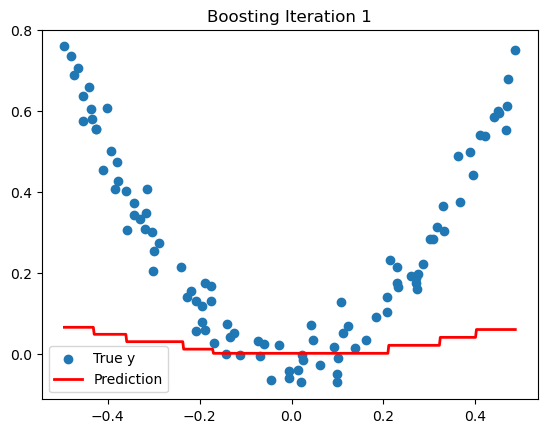

Iteration 2


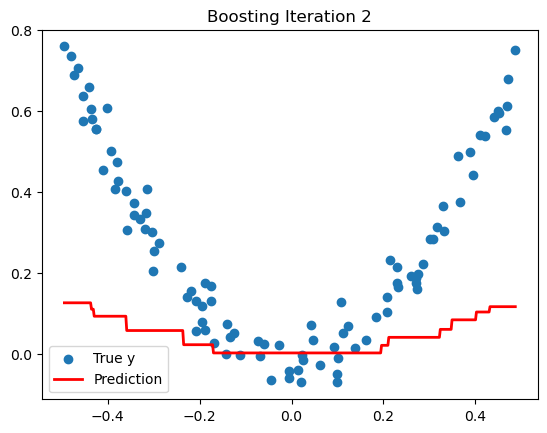

Iteration 3


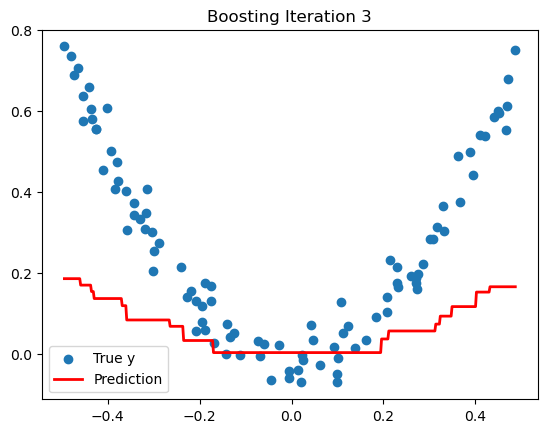

Iteration 4


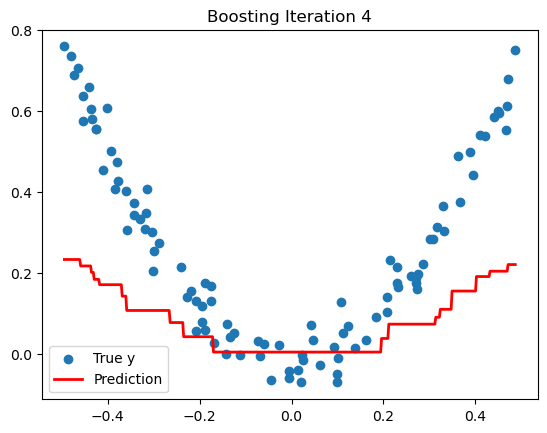

Iteration 5


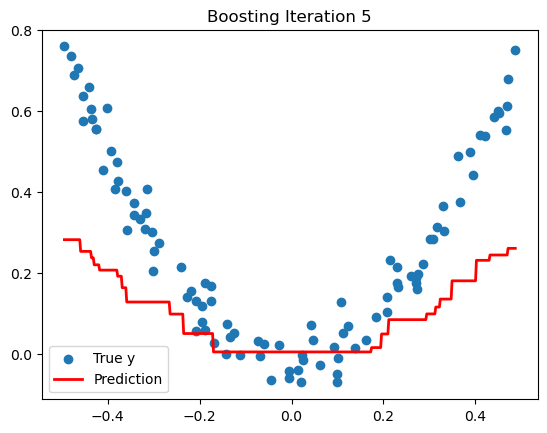

Iteration 6


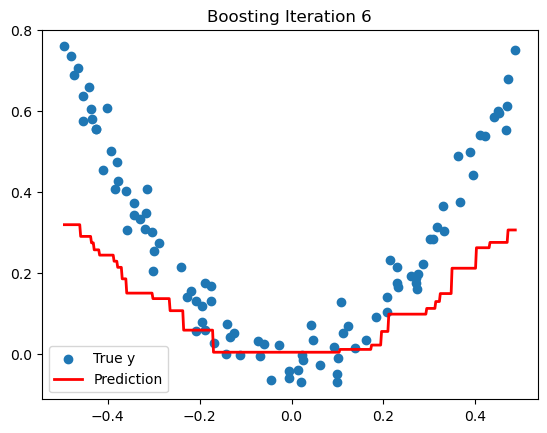

Iteration 7


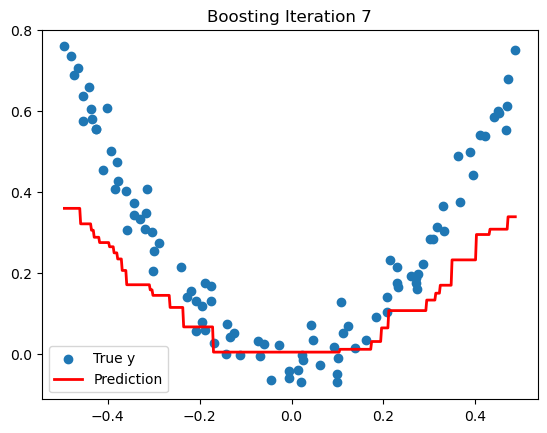

Iteration 8


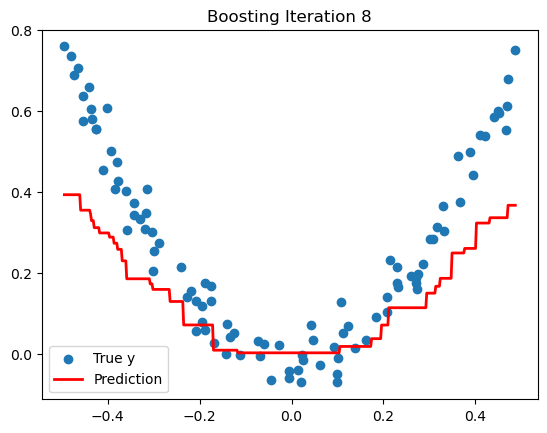

Iteration 9


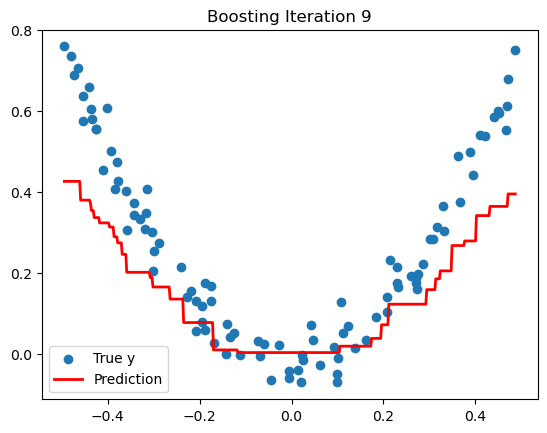

Iteration 10


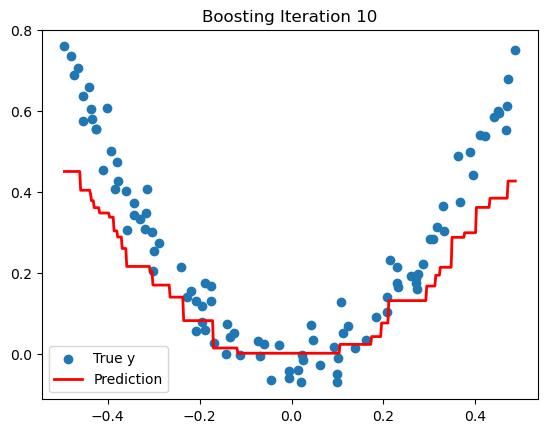

Iteration 11


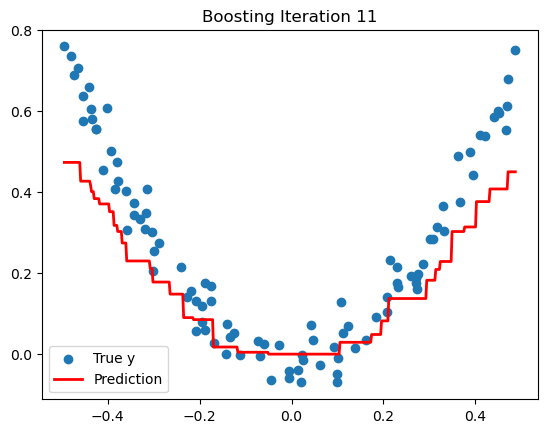

Iteration 12


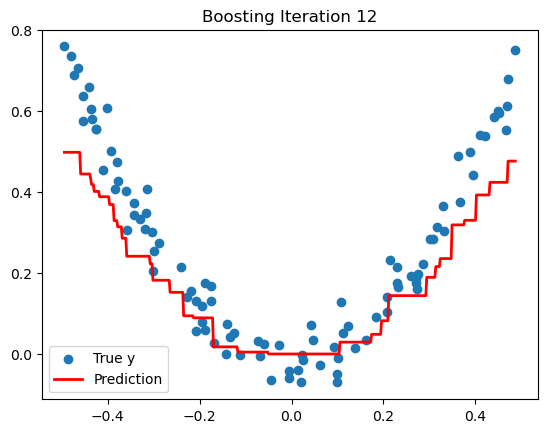

Iteration 13


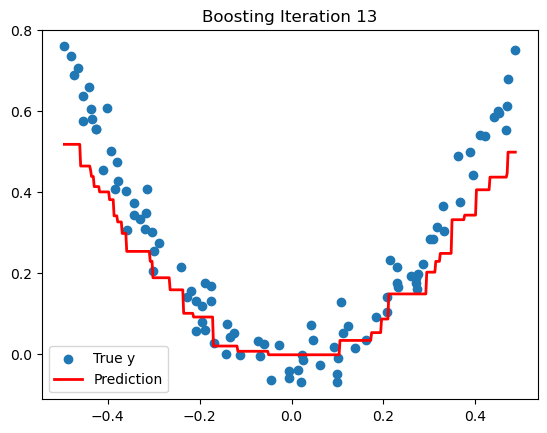

Iteration 14


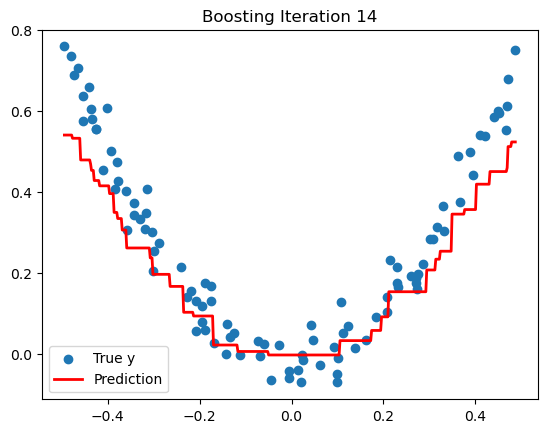

Iteration 15


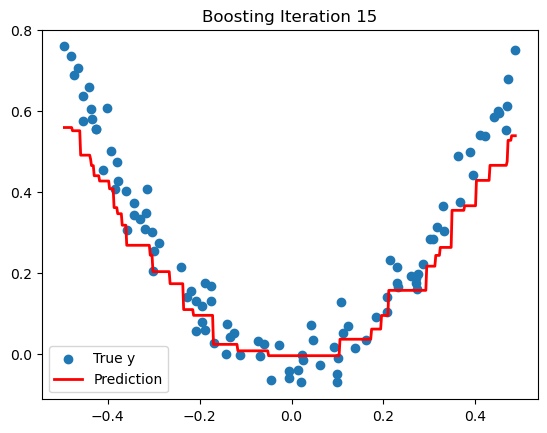

Iteration 16


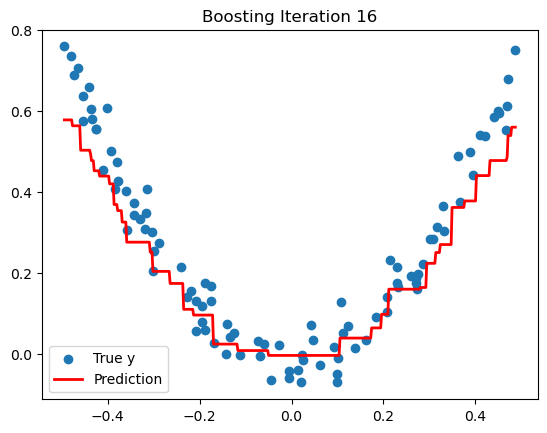

Iteration 17


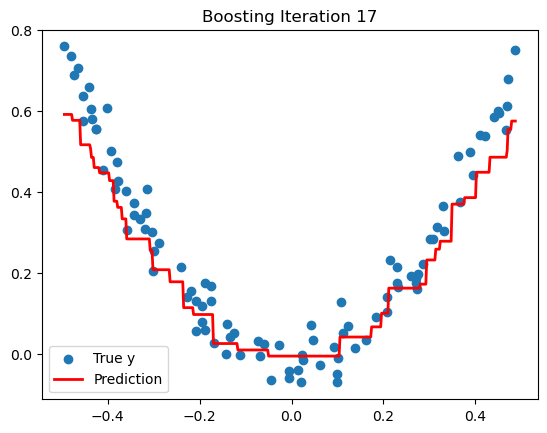

Iteration 18


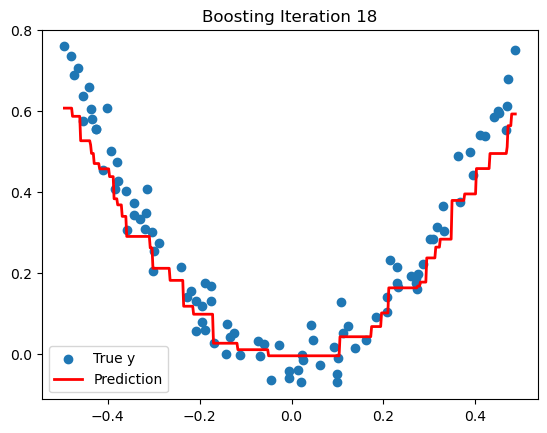

Iteration 19


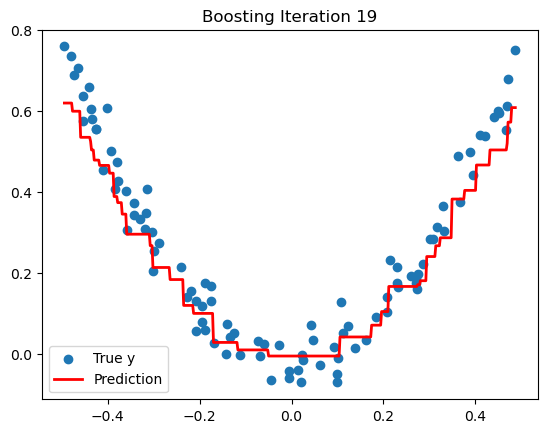

Iteration 20


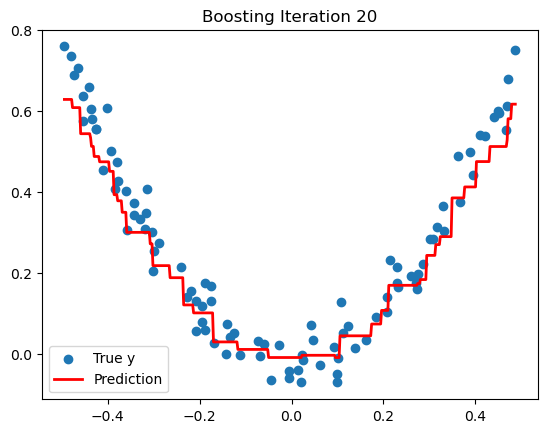

In [12]:
# X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
# y = y.reshape(-1, 1)

# df = gradient_boost(X, y, number=5, lr=0.1)
# print(df.head())

np.random.seed(42)
X= np.random.rand(100,1)-0.5
y = 3*X[:,0]**2+ 0.05* np.random.randn(100)
df = gradient_boost(X,y,20,0.1)

In [13]:
df.head()

,X,y,residual1,pred1,residual2,pred2,residual3,pred3,residual4,pred4,...,residual16,pred16,residual17,pred17,residual18,pred18,residual19,pred19,residual20,pred20
0,-0.125460,0.051573,0.051573,0.001832,0.049741,0.002784,0.048789,0.003641,0.047932,0.004898,...,0.027616,0.024618,0.026955,0.026012,0.025561,0.026742,0.024830,0.028761,0.022812,0.029986
1,0.450714,0.594480,0.594480,0.060588,0.533891,0.117035,0.477445,0.166212,0.428268,0.204607,...,0.128386,0.477946,0.116534,0.486152,0.108328,0.495280,0.099200,0.504074,0.090405,0.512557
2,0.231994,0.166052,0.166052,0.021578,0.144473,0.041309,0.124743,0.057013,0.109038,0.073878,...,0.008725,0.160199,0.005853,0.162784,0.003268,0.163514,0.002537,0.166956,-0.000905,0.169790
3,0.098658,-0.070178,-0.070178,0.001832,-0.072010,0.002784,-0.072962,0.003641,-0.073819,0.004898,...,-0.066161,-0.003357,-0.066821,-0.005002,-0.065176,-0.004271,-0.065907,-0.004852,-0.065326,-0.008657
4,-0.343981,0.343986,0.343986,0.030596,0.313389,0.058133,0.285853,0.084196,0.259790,0.107652,...,0.075330,0.276346,0.067640,0.284333,0.059653,0.290488,0.053498,0.296027,0.047959,0.300594
